# Leading proton containment vs. reconstructed momentum

This notebook checks whether the leading proton in selected `1muNp0pi_Nge1_uncontained` events is contained within the TPC, and how that relates to its reconstructed momentum. The goal is to decide whether the selection should require the leading proton to be contained outright, or whether an upper bound on the reconstructed proton momentum is an adequate substitute.

In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

data_file = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root'

with uproot.open(data_file) as f:
    tree = f['events/full/selected']
    arrs = tree.arrays([
        'reco_leading_proton_momentum',
        'reco_leading_proton_containment',
        'true_leading_proton_momentum',
        'true_category',
    ], library='np')


## Signal selection

`true_category` labels the truth-level topology of every selected event: 0 = signal QE, 1 = signal MEC, 2 = signal RES/DIS/other. We restrict this study to those three in-fiducial-volume signal categories, since these are the events whose proton momentum actually enters the cross-section measurement.

In [2]:
signal_mask = np.isin(arrs['true_category'], [0, 1, 2])

reco_pp = arrs['reco_leading_proton_momentum'][signal_mask]
reco_contained = arrs['reco_leading_proton_containment'][signal_mask]

finite = np.isfinite(reco_pp)
reco_pp = reco_pp[finite]
reco_contained = reco_contained[finite]

n_total = len(reco_pp)
n_uncontained = np.sum(reco_contained == 0)
print(f'Signal events: {n_total}')
print(f'Uncontained leading protons: {n_uncontained} ({100 * n_uncontained / n_total:.2f}%)')


Signal events: 87976
Uncontained leading protons: 2642 (3.00%)


## Uncontained fraction as a function of reconstructed momentum

If containment were purely a function of proton momentum, a momentum cut would fully reproduce a containment cut. We bin events in reconstructed proton momentum and, in each bin, compute the fraction that is flagged as uncontained.

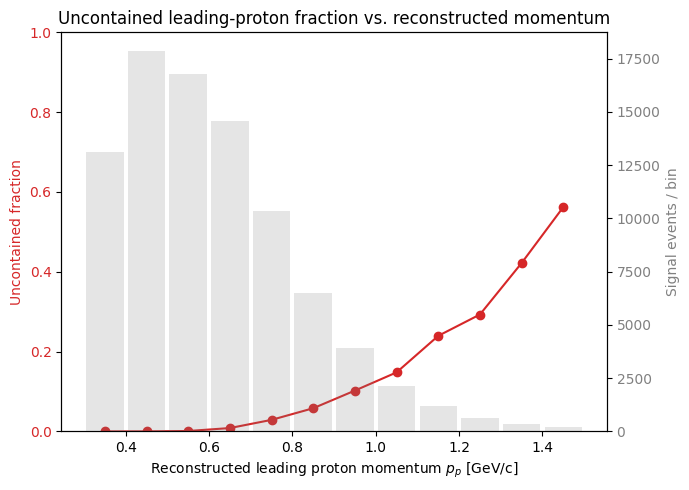

In [3]:
bins = np.linspace(0.3, 1.5, 13)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
uncontained_frac = np.full(len(bin_centers), np.nan)
counts = np.zeros(len(bin_centers), dtype=int)

for i, (lo, hi) in enumerate(zip(bins[:-1], bins[1:])):
    m = (reco_pp >= lo) & (reco_pp < hi)
    counts[i] = m.sum()
    if counts[i] > 0:
        uncontained_frac[i] = np.mean(reco_contained[m] == 0)

fig, ax1 = plt.subplots(figsize=(7, 5))
ax1.plot(bin_centers, uncontained_frac, 'o-', color='tab:red')
ax1.set_xlabel(r'Reconstructed leading proton momentum $p_p$ [GeV/c]')
ax1.set_ylabel('Uncontained fraction', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.set_ylim(0, 1.0)

ax2 = ax1.twinx()
ax2.bar(bin_centers, counts, width=0.9 * (bins[1] - bins[0]), alpha=0.2, color='gray')
ax2.set_ylabel('Signal events / bin', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

plt.title('Uncontained leading-proton fraction vs. reconstructed momentum')
plt.tight_layout()
plt.savefig('jpeg/proton_containment_vs_momentum.jpeg', dpi=150, bbox_inches='tight')
plt.show()


The uncontained fraction is negligible below ~0.7 GeV/c and rises steeply above it, reaching more than 50% by 1.4-1.5 GeV/c. This confirms the expected trend (longer, more energetic protons are more likely to reach the TPC boundary), but the correlation is not sharp: containment also depends on the proton's emission angle and vertex position, not on momentum alone. A momentum cut can therefore only be a blunt approximation of a containment requirement.

## Comparing a containment cut against a momentum cut

For a range of candidate upper bounds on the reconstructed proton momentum, we compute:

- the fraction of signal events retained,
- the fraction of the *retained* sample that is still uncontained (a bias that leaks through the cut),
- the fraction of *contained* signal events that get needlessly rejected by the momentum cut.

These are compared directly to the exact containment requirement (`reco_leading_proton_containment == 1`).

In [4]:
n_contained_total = np.sum(reco_contained == 1)

print(f'{"cut":<22}{"kept":>10}{"kept [%]":>12}{"leak [%]":>12}{"contained lost [%]":>22}')
for pmax in [0.8, 0.9, 1.0, 1.1, 1.2]:
    below = reco_pp < pmax
    n_below = below.sum()
    n_leak = np.sum((reco_contained == 0) & below)
    n_lost = np.sum((reco_contained == 1) & (~below))
    print(f'p < {pmax:.1f} GeV/c'.ljust(22)
          + f'{n_below:>10d}'
          + f'{100 * n_below / n_total:>11.1f}%'
          + f'{100 * n_leak / n_below:>11.2f}%'
          + f'{100 * n_lost / n_contained_total:>21.2f}%')

n_kept_containment = n_contained_total
print()
print('containment cut'.ljust(22)
      + f'{n_kept_containment:>10d}'
      + f'{100 * n_kept_containment / n_total:>11.1f}%'
      + f'{0.0:>11.2f}%'
      + f'{0.0:>21.2f}%')


cut                         kept    kept [%]    leak [%]    contained lost [%]
p < 0.8 GeV/c              72654       82.6%       0.61%                15.38%
p < 0.9 GeV/c              79142       90.0%       1.04%                 8.22%
p < 1.0 GeV/c              83060       94.4%       1.47%                 4.10%
p < 1.1 GeV/c              85189       96.8%       1.80%                 1.97%
p < 1.2 GeV/c              86404       98.2%       2.11%                 0.89%

containment cut            85334       97.0%       0.00%                 0.00%


## Conclusion

The direct containment cut keeps about 97% of signal events with, by construction, zero uncontained protons leaking through. Any momentum-only cut has to trade the two failure modes against each other: a tight bound (e.g. 0.8 GeV/c) still lets through ~0.6% uncontained protons while throwing away ~15% of otherwise-good contained events, and a looser bound (e.g. 1.2 GeV/c) still leaks ~2% uncontained protons for a smaller efficiency loss. Because containment depends on the full trajectory (direction and vertex position), not on momentum alone, no single momentum threshold reproduces it cleanly.

Based on this, the selection should apply the explicit containment requirement on the leading proton (`contained_protons_only`, added to `1muNp0pi_Nge1_uncontained.toml`) rather than an upper bound on the reconstructed proton momentum.